# SCHISM Idealized Run — Closed-Basin Seiche (real model output)

**Runnable companion to [`schism-model-guide.md`](../schism-model-guide.md) §17a
(Idealized test case).**

SCHISM is an **unstructured-grid** model, so there's no single "regular grid" to
chop up — this notebook plots **real output** from a SCHISM 2-D barotropic run on
a triangular mesh. The case is a self-contained **seiche**: a closed rectangular
basin given an initial cosine surface tilt, which then oscillates as a standing
wave (no external forcing, no data).

```bash
# Build (conda gfortran; SCHISM bundles ParMETIS):
cmake -C ../cmake/SCHISM.conda ../src && make -j4   # → pschism_BLD_STANDALONE_TVD-VL

# Run with scribe I/O (LC_ALL=C). nscribes >= number of output variables:
LC_ALL=C mpirun -np 6 ./pschism 4                   # 2 compute + 4 scribe ranks
```

> **Gotchas getting a minimal SCHISM case to run:**
> 1. **`itur=0`** — a 2-D barotropic run has no turbulence closure; the default
>    `itur=3` (GLS) demands `diffmin/diffmax.gr3` and aborts without them.
> 2. **scribes ≥ #output-variables** — SCHISM aborts with "Too few scribes"
>    otherwise (4 here: elevation + velocity + z-coords).
> 3. **`LC_ALL=C`** for the locale; a self-built `hgrid.gr3` with a closed
>    land-boundary ring and `bctides.in` with `nope=0`.

Committed: a compact extract (elevation on 306 nodes, 24 frames, mesh + triangles).

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from meteo_examples import sampledata

ds = xr.open_dataset(sampledata.schism_seiche_path())
x, y = ds["node_x"].values, ds["node_y"].values
tri = mtri.Triangulation(x / 1000, y / 1000, ds["tri"].values - 1)   # km, 0-based
t = ds["time_h"].values
elev = ds["elevation"].values
plt.rcParams["figure.dpi"] = 110
print(ds.attrs["title"])
print(f"{ds.sizes['node']} nodes, {ds.sizes['face']} triangles, {len(t)} frames")

Compact real SCHISM seiche output (closed basin, 2D barotropic)
306 nodes, 500 triangles, 24 frames


## 1 · The standing wave on the unstructured mesh

Snapshots of free-surface elevation. The basin sloshes: high at one end, low at
the other, reversing each half-period — the fundamental seiche mode.

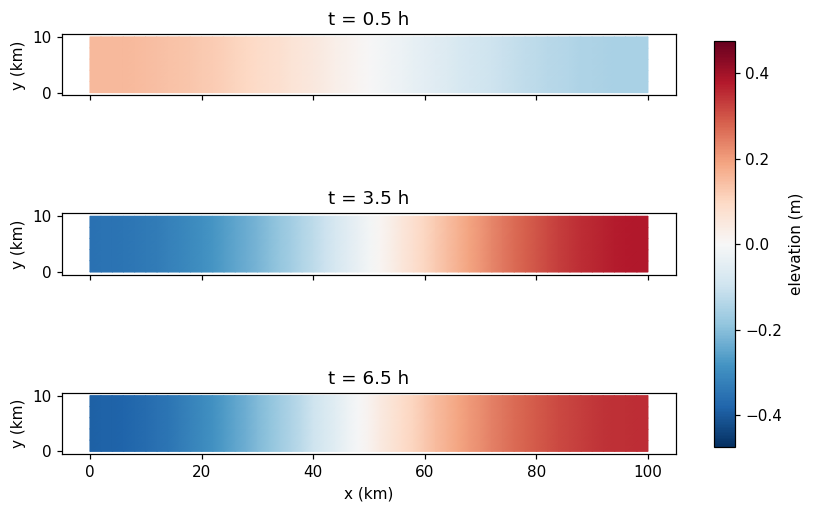

In [2]:
picks = [0, len(t)//4, len(t)//2]
vmax = np.abs(elev).max()
fig, axes = plt.subplots(len(picks), 1, figsize=(9, 6), sharex=True)
for ax, k in zip(axes, picks):
    tpc = ax.tripcolor(tri, elev[k], cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="gouraud")
    ax.set(ylabel="y (km)", title=f"t = {t[k]:.1f} h")
    ax.set_aspect("equal")
axes[-1].set_xlabel("x (km)")
fig.colorbar(tpc, ax=axes, label="elevation (m)", shrink=0.8)
plt.show()

## 2 · The mesh itself

A look at the triangular grid SCHISM actually solves on (every model variable
lives on these nodes).

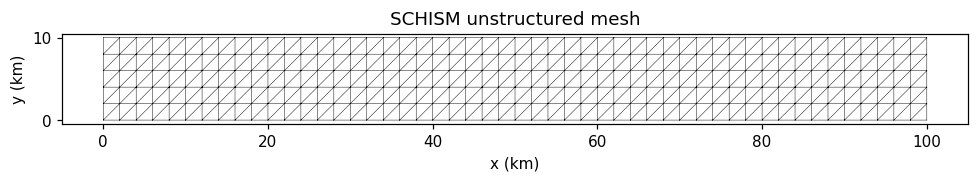

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.triplot(tri, color="k", lw=0.3)
ax.set(xlabel="x (km)", ylabel="y (km)", title="SCHISM unstructured mesh")
ax.set_aspect("equal"); plt.tight_layout()

## 3 · Seiche oscillation at the basin ends

Elevation at the two ends oscillates out of phase — the standing-wave signature.
The period matches shallow-water theory: T = 2L/√(gH).

theoretical seiche period T = 2L/sqrt(gH) = 2.51 h (L=100 km, H=50 m)


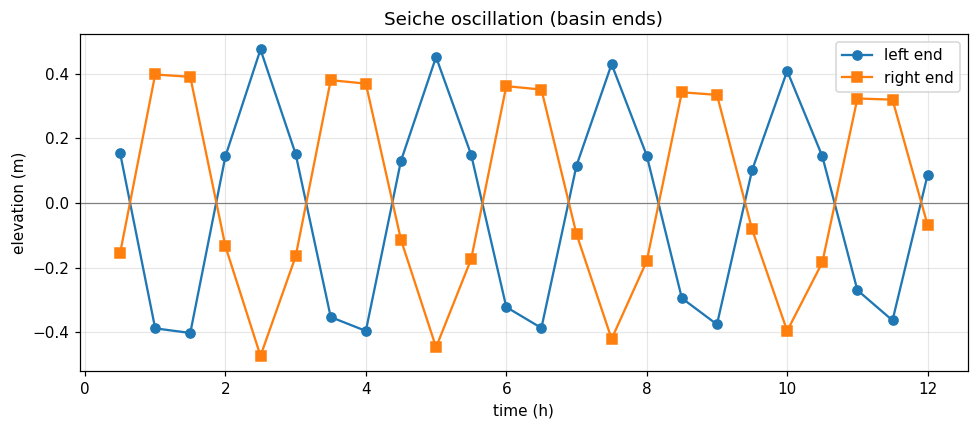

In [4]:
iL = int(np.argmin(x)); iR = int(np.argmax(x))      # left & right end nodes
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, elev[:, iL], "o-", label="left end")
ax.plot(t, elev[:, iR], "s-", label="right end")
ax.axhline(0, color="gray", lw=0.8)
ax.set(xlabel="time (h)", ylabel="elevation (m)", title="Seiche oscillation (basin ends)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
L = x.max() - x.min(); T = 2 * L / np.sqrt(9.81 * 50) / 3600
print(f"theoretical seiche period T = 2L/sqrt(gH) = {T:.2f} h (L={L/1000:.0f} km, H=50 m)")

---
### Reproduce / extend
- Build with `cmake -C cmake/SCHISM.conda ../src` (SCHISM bundles ParMETIS).
- For a real-data run, generate a mesh + forcing with **pyschism** / OceanMesh2D
  and tides via `bctides.in` (FES2022/TPXO10) — see the SCHISM guide §13 and the
  Sunda/Lombok worked example §17b.
- Read SCHISM's unstructured output by mapping the `nSCHISM_hgrid_node`
  dimension + `SCHISM_hgrid_face_nodes` triangles, as done above.